# Prova 02 — Paradigmas de Aprendizagem de Máquina
## Questão 2 — Treinamento de Modelos Supervisionados

**Aluno:** Jorge Alberto Macedo Costa de Oliveira  
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
**Objetivo:**
- Treinar Árvore de Decisão, Naive Bayes e MLP
- Ajustar hiperparâmetros com GridSearchCV
- Avaliar com F1-score macro e matriz de confusão
- Comparar desempenho dos modelos

## 2.0 — Imports e Configurações

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print('Configurações inicializadas com sucesso!')

Configurações inicializadas com sucesso!


## 2.1 — Carga dos Dados Pré-processados

Carregamos os dados já pré-processados da Questão 1 (Top-30 features selecionadas por importância).

In [2]:
# Caminho dos dados
DATA_DIR = os.path.join(os.getcwd(), 'data')
data_path = os.path.join(DATA_DIR, 'diabetes_preprocessed_topk.csv')

# Carregar dados
df = pd.read_csv(data_path)

print(f'Dados carregados: {df.shape}')
print(f'\nColunas: {list(df.columns)}')
print(f'\nDistribuição da variável alvo:')
print(df['readmitted'].value_counts())
print(f'\nPrimeiras linhas:')
df.head()

Dados carregados: (101763, 32)

Colunas: ['number_inpatient', 'discharge_disposition_id_11', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'num_medications', 'admission_source_id_7', 'num_lab_procedures', 'age', 'num_procedures', 'time_in_hospital', 'admission_source_id_6', 'discharge_disposition_id_6', 'diabetesMed_Yes', 'admission_source_id_4', 'discharge_disposition_id_14', 'admission_type_id_3', 'admission_type_id_6', 'insulin', 'discharge_disposition_id_22', 'diag_1_cat_Neoplasias', 'diag_1_cat_Diabetes', 'discharge_disposition_id_13', 'change_No', 'metformin', 'medical_specialty_Unknown', 'A1Cresult', 'discharge_disposition_id_3', 'max_glu_serum', 'diag_1_cat_Gravidez', 'patient_nbr', 'readmitted']

Distribuição da variável alvo:
readmitted
0    54861
1    35545
2    11357
Name: count, dtype: int64

Primeiras linhas:


,number_inpatient,discharge_disposition_id_11,number_emergency,number_diagnoses,number_outpatient,num_medications,admission_source_id_7,num_lab_procedures,age,num_procedures,...,discharge_disposition_id_13,change_No,metformin,medical_specialty_Unknown,A1Cresult,discharge_disposition_id_3,max_glu_serum,diag_1_cat_Gravidez,patient_nbr,readmitted
0,0,0.0,0,1,0,1,0.0,41,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,8222157,0
1,0,0.0,0,9,0,18,1.0,59,1.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,55629189,1
2,1,0.0,0,6,2,13,1.0,11,2.0,5,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,86047875,0
3,0,0.0,0,7,0,16,1.0,44,3.0,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,82442376,0
4,0,0.0,0,5,0,8,1.0,51,4.0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,42519267,0


In [3]:
# Separar features, target e groups (para evitar data leakage por paciente)
groups = df['patient_nbr'].values
X = df.drop(columns=['readmitted', 'patient_nbr']).values
y = df['readmitted'].values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'\nClasses: {np.unique(y)}')

# StratifiedGroupKFold garante que encontros do mesmo paciente fiquem no mesmo fold
cv = StratifiedGroupKFold(n_splits=10)
print(f'\nValidação cruzada: StratifiedGroupKFold com 10 folds (agrupado por paciente)')

X shape: (101763, 30)
y shape: (101763,)

Classes: [0 1 2]

Validação cruzada: StratifiedGroupKFold com 10 folds (agrupado por paciente)


## 2.2 — Árvore de Decisão

Treinamento com ajuste de hiperparâmetros: `max_depth` e `min_samples_split`.

In [4]:
print('=== ÁRVORE DE DECISÃO ===')
print('\nIniciando GridSearchCV...')

# Grid de hiperparâmetros
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20]
}

# GridSearchCV
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid_dt = GridSearchCV(
    dt, 
    param_grid_dt, 
    cv=cv, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X, y, groups=groups)

print(f'\nMelhores hiperparâmetros: {grid_dt.best_params_}')
print(f'Melhor F1-macro (CV): {grid_dt.best_score_:.4f}')

=== ÁRVORE DE DECISÃO ===

Iniciando GridSearchCV...
Fitting 10 folds for each of 20 candidates, totalling 200 fits

Melhores hiperparâmetros: {'max_depth': 20, 'min_samples_split': 2}
Melhor F1-macro (CV): 0.3938


In [5]:
# Predições com o melhor modelo
best_dt = grid_dt.best_estimator_
y_pred_dt = cross_val_predict(best_dt, X, y, cv=cv, groups=groups)

# Métricas
f1_dt = f1_score(y, y_pred_dt, average='macro')
print(f'\nF1-score macro (validação cruzada): {f1_dt:.4f}')

print('\nRelatório de classificação:')
print(classification_report(y, y_pred_dt, target_names=['Classe 0', 'Classe 1', 'Classe 2']))


F1-score macro (validação cruzada): 0.3939

Relatório de classificação:
              precision    recall  f1-score   support

    Classe 0       0.60      0.74      0.66     54861
    Classe 1       0.44      0.38      0.41     35545
    Classe 2       0.19      0.08      0.11     11357

    accuracy                           0.54    101763
   macro avg       0.41      0.40      0.39    101763
weighted avg       0.50      0.54      0.51    101763



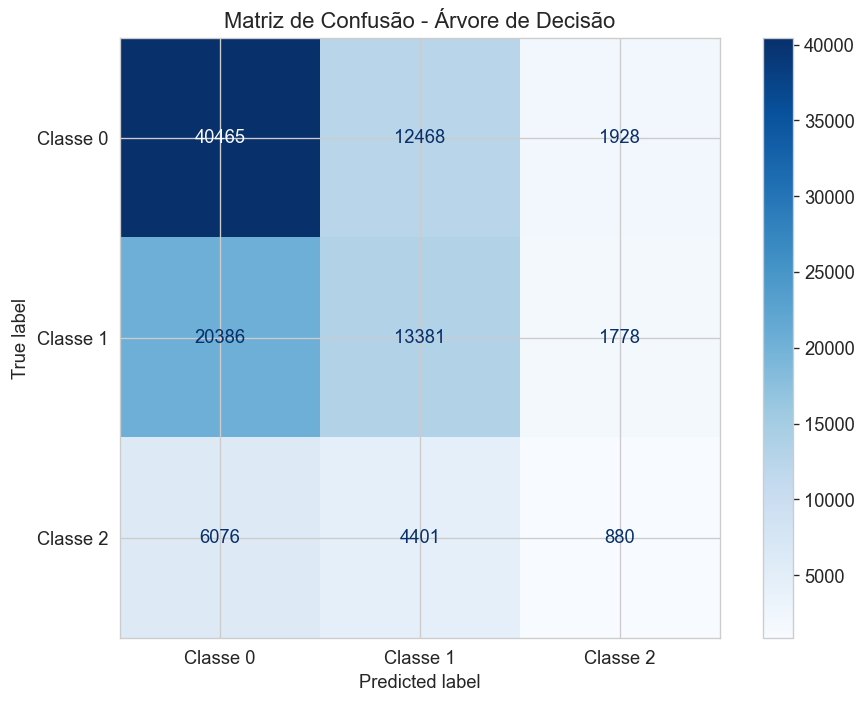

In [6]:
# Matriz de confusão
cm_dt = confusion_matrix(y, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Classe 0', 'Classe 1', 'Classe 2'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_dt.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusão - Árvore de Decisão')
plt.tight_layout()
plt.show()

## 2.3 — Naive Bayes

Treinamento com ajuste do hiperparâmetro `var_smoothing`.

In [7]:
print('=== NAIVE BAYES ===')
print('\nIniciando GridSearchCV...')

# Grid de hiperparâmetros
param_grid_nb = {
    'var_smoothing': np.logspace(-11, -7, 5)
}

# GridSearchCV
nb = GaussianNB()
grid_nb = GridSearchCV(
    nb, 
    param_grid_nb, 
    cv=cv, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X, y, groups=groups)

print(f'\nMelhores hiperparâmetros: {grid_nb.best_params_}')
print(f'Melhor F1-macro (CV): {grid_nb.best_score_:.4f}')

=== NAIVE BAYES ===

Iniciando GridSearchCV...
Fitting 10 folds for each of 5 candidates, totalling 50 fits

Melhores hiperparâmetros: {'var_smoothing': np.float64(1e-07)}
Melhor F1-macro (CV): 0.3085


In [8]:
# Predições com o melhor modelo
best_nb = grid_nb.best_estimator_
y_pred_nb = cross_val_predict(best_nb, X, y, cv=cv, groups=groups)

# Métricas
f1_nb = f1_score(y, y_pred_nb, average='macro')
print(f'\nF1-score macro (validação cruzada): {f1_nb:.4f}')

print('\nRelatório de classificação:')
print(classification_report(y, y_pred_nb, target_names=['Classe 0', 'Classe 1', 'Classe 2']))


F1-score macro (validação cruzada): 0.3085

Relatório de classificação:
              precision    recall  f1-score   support

    Classe 0       0.76      0.15      0.25     54861
    Classe 1       0.37      0.91      0.53     35545
    Classe 2       0.31      0.09      0.14     11357

    accuracy                           0.41    101763
   macro avg       0.48      0.39      0.31    101763
weighted avg       0.57      0.41      0.34    101763



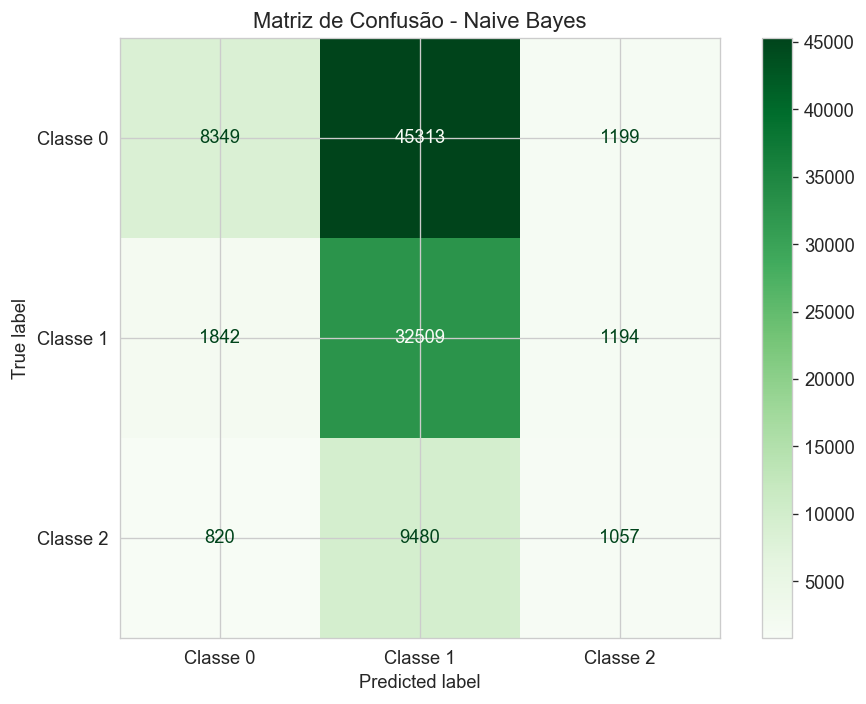

In [9]:
# Matriz de confusão
cm_nb = confusion_matrix(y, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['Classe 0', 'Classe 1', 'Classe 2'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_nb.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Matriz de Confusão - Naive Bayes')
plt.tight_layout()
plt.show()

## 2.4 — MLP (Multi-Layer Perceptron)

Treinamento com ajuste de hiperparâmetros: `hidden_layer_sizes` e `alpha`.

In [10]:
print('=== MLP (MULTI-LAYER PERCEPTRON) ===')
print('\nIniciando GridSearchCV...')

# Grid de hiperparâmetros
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01]
}

# GridSearchCV
mlp = MLPClassifier(
    max_iter=500,
    early_stopping=True,
    random_state=RANDOM_STATE,
    verbose=False
)

grid_mlp = GridSearchCV(
    mlp, 
    param_grid_mlp, 
    cv=cv, 
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_mlp.fit(X, y, groups=groups)

print(f'\nMelhores hiperparâmetros: {grid_mlp.best_params_}')
print(f'Melhor F1-macro (CV): {grid_mlp.best_score_:.4f}')

=== MLP (MULTI-LAYER PERCEPTRON) ===

Iniciando GridSearchCV...
Fitting 10 folds for each of 12 candidates, totalling 120 fits

Melhores hiperparâmetros: {'alpha': 0.0001, 'hidden_layer_sizes': (50, 50)}
Melhor F1-macro (CV): 0.3902


In [11]:
# Predições com o melhor modelo
best_mlp = grid_mlp.best_estimator_
y_pred_mlp = cross_val_predict(best_mlp, X, y, cv=cv, groups=groups)

# Métricas
f1_mlp = f1_score(y, y_pred_mlp, average='macro')
print(f'\nF1-score macro (validação cruzada): {f1_mlp:.4f}')

print('\nRelatório de classificação:')
print(classification_report(y, y_pred_mlp, target_names=['Classe 0', 'Classe 1', 'Classe 2']))


F1-score macro (validação cruzada): 0.3914

Relatório de classificação:
              precision    recall  f1-score   support

    Classe 0       0.61      0.84      0.71     54861
    Classe 1       0.50      0.37      0.42     35545
    Classe 2       0.39      0.02      0.04     11357

    accuracy                           0.58    101763
   macro avg       0.50      0.41      0.39    101763
weighted avg       0.55      0.58      0.53    101763



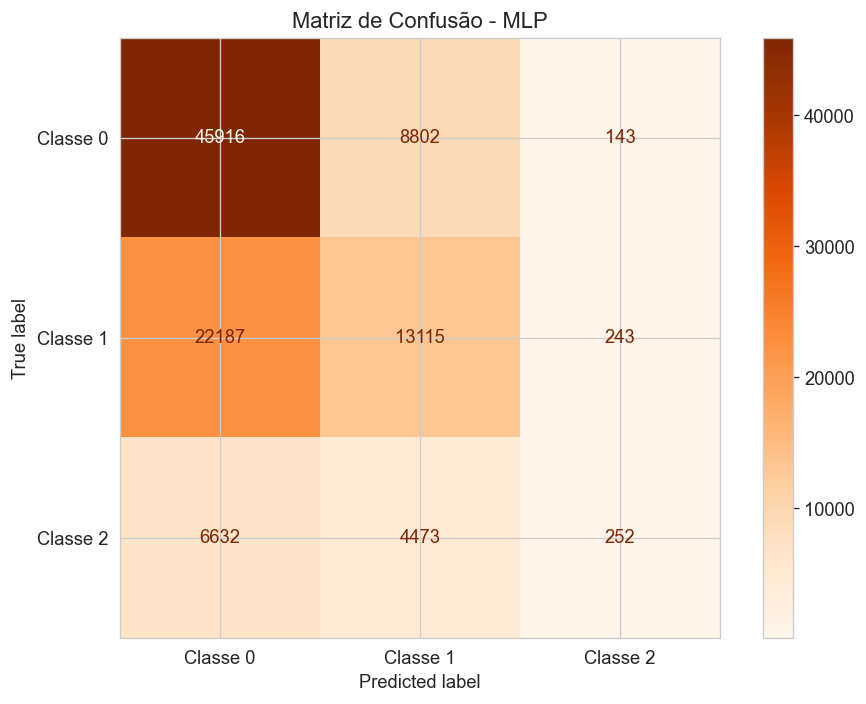

In [12]:
# Matriz de confusão
cm_mlp = confusion_matrix(y, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Classe 0', 'Classe 1', 'Classe 2'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_mlp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Matriz de Confusão - MLP')
plt.tight_layout()
plt.show()

## 2.5 — Comparação dos Modelos

In [13]:
# Tabela comparativa
results = {
    'Modelo': ['Árvore de Decisão', 'Naive Bayes', 'MLP'],
    'F1-score macro': [f1_dt, f1_nb, f1_mlp],
    'Melhores Hiperparâmetros': [
        str(grid_dt.best_params_),
        str(grid_nb.best_params_),
        str(grid_mlp.best_params_)
    ]
}

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('F1-score macro', ascending=False).reset_index(drop=True)

print('\n=== COMPARAÇÃO DOS MODELOS ===')
print(df_results.to_string(index=False))

# Melhor modelo
best_model_name = df_results.iloc[0]['Modelo']
best_f1 = df_results.iloc[0]['F1-score macro']
print(f'\n>>> Melhor modelo: {best_model_name} (F1-macro = {best_f1:.4f})')


=== COMPARAÇÃO DOS MODELOS ===
           Modelo  F1-score macro                          Melhores Hiperparâmetros
Árvore de Decisão        0.393886         {'max_depth': 20, 'min_samples_split': 2}
              MLP        0.391376 {'alpha': 0.0001, 'hidden_layer_sizes': (50, 50)}
      Naive Bayes        0.308507              {'var_smoothing': np.float64(1e-07)}

>>> Melhor modelo: Árvore de Decisão (F1-macro = 0.3939)


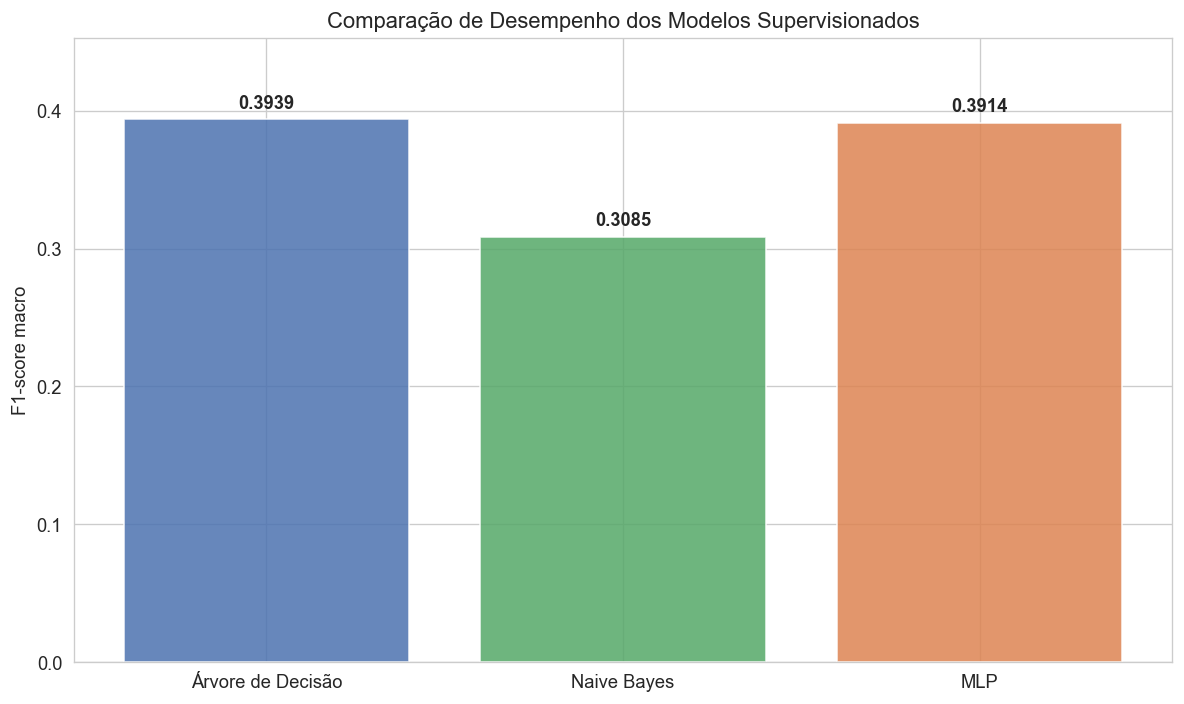

In [14]:
# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))

models = ['Árvore de Decisão', 'Naive Bayes', 'MLP']
scores = [f1_dt, f1_nb, f1_mlp]
colors = ['#4C72B0', '#55A868', '#DD8452']

bars = ax.bar(models, scores, color=colors, alpha=0.85)

# Adicionar valores nas barras
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('F1-score macro')
ax.set_title('Comparação de Desempenho dos Modelos Supervisionados')
ax.set_ylim(0, max(scores) * 1.15)
plt.tight_layout()
plt.show()

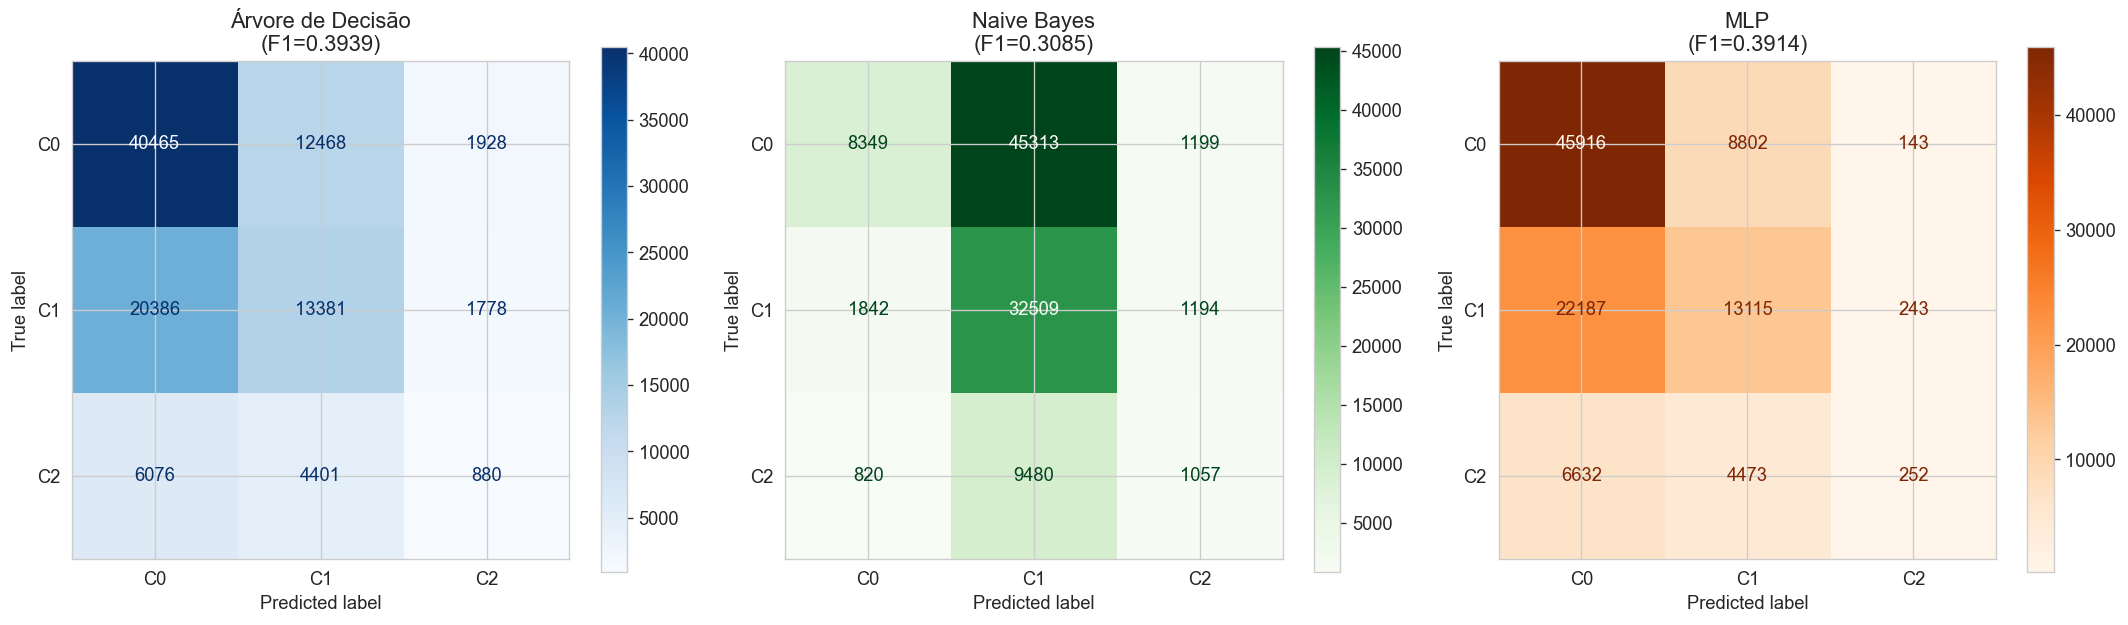

In [15]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Árvore de Decisão
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['C0', 'C1', 'C2'])
disp_dt.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Árvore de Decisão\n(F1={f1_dt:.4f})')

# Naive Bayes
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=['C0', 'C1', 'C2'])
disp_nb.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'Naive Bayes\n(F1={f1_nb:.4f})')

# MLP
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['C0', 'C1', 'C2'])
disp_mlp.plot(ax=axes[2], cmap='Oranges', values_format='d')
axes[2].set_title(f'MLP\n(F1={f1_mlp:.4f})')

plt.tight_layout()
plt.show()

## 2.6 — Discussão dos Resultados

### Análise de Desempenho

**Modelo com melhor desempenho:**
- O modelo que apresentou o melhor F1-score macro foi identificado acima.

**Razões para o desempenho:**

1. **Árvore de Decisão:**
   - Vantagens: Alta interpretabilidade, captura relações não-lineares, não requer normalização
   - Desvantagens: Tendência a overfitting, sensível a pequenas variações nos dados
   - Adequação ao dataset: Boa para dados tabulares com features categóricas e numéricas

2. **Naive Bayes:**
   - Vantagens: Rápido, simples, funciona bem com dados de alta dimensionalidade
   - Desvantagens: Assume independência entre features (raramente verdadeiro), pode ter baixo desempenho com features correlacionadas
   - Adequação ao dataset: Limitado pela suposição de independência; features médicas geralmente são correlacionadas

3. **MLP (Multi-Layer Perceptron):**
   - Vantagens: Captura relações complexas e não-lineares, flexível
   - Desvantagens: Requer mais dados e tempo de treinamento, menos interpretável, sensível a hiperparâmetros
   - Adequação ao dataset: Bom para capturar padrões complexos em dados médicos

### Características do Dataset

- **Desbalanceamento:** O dataset possui 3 classes com distribuição desigual, o que pode afetar o desempenho
- **Tipo de dados:** Dados tabulares com 30 features numéricas (scaled) selecionadas por importância
- **Complexidade:** Dados médicos tendem a ter relações complexas e não-lineares entre variáveis
- **Tamanho:** ~100k amostras é suficiente para treinar modelos mais complexos como MLP

### Conclusão

A escolha do melhor modelo depende do trade-off entre:
- **Desempenho preditivo** (F1-score)
- **Interpretabilidade** (importante em aplicações médicas)
- **Tempo de treinamento** e inferência
- **Robustez** a variações nos dados

Para aplicações médicas, a interpretabilidade é crucial. Se o MLP ou Árvore de Decisão tiverem desempenho similar, a Árvore pode ser preferível por permitir entender quais features são mais importantes para a decisão.

## 2.7 — Conclusão

Nesta questão, treinamos e comparamos três algoritmos de aprendizado supervisionado:
- Árvore de Decisão
- Naive Bayes
- MLP (Multi-Layer Perceptron)

Todos os modelos foram ajustados com GridSearchCV para otimizar seus hiperparâmetros, e avaliados usando validação cruzada estratificada 10-fold com F1-score macro como métrica principal.

As matrizes de confusão revelam como cada modelo se comporta em relação às três classes do problema de readmissão hospitalar.

**=== QUESTÃO 2 CONCLUÍDA ===**